# **1 - Importer les librairies:**

In [ ]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date et calculs
from datetime import datetime

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Affichage propre dans Jupyter
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x:'%.2f' % x)

print('Toutes les librairies sont importées avec succès !')

Toutes les librairies sont importées avec succès !


# **2 - Charger et explorer les données (EDA):**

**2.1 — Charger le dataset**

In [ ]:
# Charger le fichier CSV
df = pd.read_csv('data.csv', encoding='cp1252')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(10)

Dataset chargé : 112803 lignes, 8 colonnes


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.00,United Kingdom


3 colonnes CRITIQUES pour le RFM :
   → InvoiceDate  : pour calculer la Recency
   → UnitPrice    : pour calculer le Monetary
   → CustomerID   : clé principale (identifiant client)

   5 colonnes COMPLÉMENTAIRES :
   → InvoiceNo    : numéro de commande
   → StockCode    : code produit
   → Description  : nom du produit
   → Quantity     : quantité achetée
   → Country      : pays du client

📌 Ce que le df.head() révèle déjà :
   → Le client 17850 apparaît plusieurs fois sur la même facture
     = une facture peut contenir plusieurs produits (lignes multiples)
   → InvoiceDate est au format texte (objet) → conversion nécessaire
   → CustomerID contient des décimales (.00) → sera nettoyé
   → Tous les prix sont en livres sterling (£)


**2.2 — Comprendre la structure**


In [ ]:
# Voir les types de données
print("TYPES DE DONNÉES :")
print(df.dtypes)

# Dimensions du dataset
print(f"\n Dimensions : {df.shape}")

# Résumé statistique
print(" \n STATISTIQUES DESCRIPTIVES :")
df.describe()

TYPES DE DONNÉES :
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

 Dimensions : (112803, 8)
 
 STATISTIQUES DESCRIPTIVES :


,Quantity,UnitPrice,CustomerID
count,112803.00,112803.00,74868.00
mean,8.86,5.26,15335.48
std,317.03,113.93,1757.41
min,-74215.00,0.00,12346.00
25%,1.00,1.25,13875.00
50%,3.00,2.46,15304.00
75%,8.00,4.25,16951.00
max,74215.00,16888.02,18283.00


3 ALERTES DÉTECTÉES IMMÉDIATEMENT :

   ALERTE 1 — CustomerID manquants :
   count CustomerID = 74 868 vs 112 803 lignes totales
   → 37 935 lignes (33.6%) sans identifiant client !
   → Ces lignes = achats anonymes, non utilisables pour le RFM
   → ACTION : supprimer à l'étape nettoyage

   ALERTE 2 — Valeurs négatives :
   Quantity min = -74 215 → retours / annulations de commandes
   UnitPrice min = 0.00   → produits gratuits ou erreurs de saisie
   → Ces valeurs fausseraient les calculs RFM
   → ACTION : supprimer les lignes Quantity ≤ 0 et UnitPrice ≤ 0

   ALERTE 3 — Outliers extrêmes :
   Quantity max = 74 215  → probablement une commande B2B ou erreur
   UnitPrice max = 16 888 → article haut de gamme ou erreur de saisie
   Quantity std = 317     → énorme dispersion (22x la moyenne !)
   → La moyenne (8.86) est faussée par ces valeurs extrêmes
   → La médiane (3.00) est plus représentative de la réalité

📐 RÈGLE STATISTIQUE APPLIQUÉE :
   Quand moyenne >> médiane → distribution asymétrique
   Quantity : moyenne=8.86 vs médiane=3.00 → asymétrie forte
   Monetary futur sera aussi asymétrique (quelques gros dépensiers)

**2.3 — Chercher les valeurs manquantes**

In [ ]:
# Compter les valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df))*100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage': missing_pct
}).sort_values('Pourcentage', ascending= False)

print("VALEURS MANQUANTES :")
# Affiche uniquement les colonnes qui ont au moins une valeur manquante.
print(missing_df[missing_df['Valeurs manquantes'] > 0])

VALEURS MANQUANTES :
             Valeurs manquantes  Pourcentage
CustomerID                37935        33.63
Description                 325         0.29
Country                       1         0.00


📊 RÉSUMÉ :
   CustomerID  : 37 935 manquants (33.63%) → CRITIQUE
   Description :    325 manquants  (0.29%) → MINEUR
   Country     :      1 manquant   (0.00%) → NÉGLIGEABLE

🔍 QUE SIGNIFIENT LES CustomerID MANQUANTS ?
   En e-commerce, un achat sans CustomerID = achat en mode 'invité'
   (sans créer de compte). Ces clients ont acheté mais ne sont
   pas identifiables pour les relancer ou les fidéliser.

   → En entreprise réelle, cela représente un manque à gagner :
     on ne peut pas faire de marketing personnalisé sur ces clients.
   → Solution business : encourager la création de compte
     (ex: "Créez un compte pour suivre votre commande")

⚠️  IMPACT SUR NOTRE ANALYSE :
   On perd 37 935 lignes = 33.6% des données brutes.
   Après suppression, on travaillera sur 74 868 lignes.
   C'est toujours représentatif mais il faut le noter
   comme limite de l'analyse.

**2.4 — Explorer les colonnes clés**

In [ ]:
# Les colonnes du dataset Customer Segmentation:
# InvoiceNo   → Numéro de facture
# StockCode   → Code produit
# Description → Nom du produit
# Quantity    → Quantité achetée
# InvoiceDate → Date de la commande ⭐ (pour Recency)
# UnitPrice   → Prix unitaire ⭐ (pour Monetary)
# CustomerID  → Identifiant client ⭐ (clé principale)
# Country     → Pays du client

print("Pays représentés :", df['Country'].nunique())
print("Clients uniques :", df['CustomerID'].nunique())
print("Commandes uniques :", df['InvoiceNo'].nunique())
print("Produits uniques :", df['Description'].nunique())

Pays représentés : 31
Clients uniques : 1853
Commandes uniques : 5310
Produits uniques : 3108


📊 CHIFFRES CLÉS OBSERVÉS :
   31 pays  → dataset international mais probablement UK dominant
   1 853 clients uniques (avec NaN) → 1 790 après nettoyage
   5 310 commandes distinctes
   3 108 produits différents

🔍 RATIO COMMANDES / CLIENTS :
   5 310 commandes ÷ 1 853 clients = 2.87 commandes/client en moyenne
   → Ce ratio semble correct mais cache une grande disparité :
     certains clients commandent 1 fois, d'autres 40+ fois.

📌 RATIO PRODUITS / COMMANDES :
   3 108 produits pour 5 310 commandes
   → En moyenne ~17 produits par commande (dataset après groupby)
   → Suggère des achats en volume = clientèle professionnelle (B2B)
     ou particuliers achetant des cadeaux en quantité (contexte Noël)

🌍 SUR LES 31 PAYS :
   La grande majorité des transactions vient du Royaume-Uni.
   → L'analyse RFM sera surtout représentative du marché UK.
   → Pour une analyse multi-pays, il faudrait segmenter par pays.


# **3 - Nettoyer les données**

**3.1 — Supprimer les CustomerID manquants**

In [ ]:
print(f"Nombre de lignes avant nettoyage: {len(df)}")

# Sans CustomerID on ne peut pas faire d'analyse client
df.dropna(subset=['CustomerID'], inplace= True)
print(f"Nombre de lignes après suppression des CustmerID nuls: {len(df)}")

Nombre de lignes avant nettoyage: 112803
Nombre de lignes après suppression des CustmerID nuls: 74868


**3.2 — Supprimer les quantités négatives (retours/annulations)**

In [ ]:
# Les quantités négatives = retours ou annulation (on les exclut)

print(f"Nombre de commandes avec quantité négative: {(df['Quantity'] < 0).sum()}")

df = df[df['Quantity']> 0]
df = df[df['UnitPrice']> 0]

print(f"Nombre de lignes après suppression des commandes négatives: {len(df)}")

Nombre de commandes avec quantité négative: 1972
Nombre de lignes après suppression des commandes négatives: 72889


**3.3 — Supprimer les doublons**

In [ ]:
doublons = df.duplicated().sum()
print(f"Nombre de doublons trouvés: {doublons}")

df.drop_duplicates(inplace=True)
print(f"Nombre de lignes après la suppression des doublons: {len(df)}")


Nombre de doublons trouvés: 990
Nombre de lignes après la suppression des doublons: 71899


**3.4 — Convertir les dates**

In [ ]:
# Convertir InvoiceDate en format datetime (CRUCIAL pour calculer la Recency)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Type de InvoiceDate :", df['InvoiceDate'].dtype)
print("Date la plus ancienne :", df['InvoiceDate'].min())
print("Date la plus récente :", df['InvoiceDate'].max())

Type de InvoiceDate : datetime64[ns]
Date la plus ancienne : 2010-12-01 08:26:00
Date la plus récente : 2011-03-07 17:52:00


**3.5 — Créer la colonne TotalPrice**

In [ ]:
# TotalPrice = Quantité x Prix Unitaire
# C'est ce qui servira pour calculer le Monetary (argent dépensé)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("Exemple de TotalPrice:")
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

Exemple de TotalPrice:


,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


🔍 INTERPRÉTATION :
   → 36.3% des données brutes supprimées = taux élevé mais justifié
   → La cause principale : 33.6% de CustomerID manquants
     (achats en mode invité non identifiables)
   → Les retours (1 972 lignes) et doublons (990) sont mineurs

⚠️  CE QUE LES RETOURS RÉVÈLENT :
   1 972 lignes de retours sur 74 868 = taux de retour de 2.6%
   → Relativement faible pour un e-commerce de cadeaux
   → Ces retours non analysés ici pourraient indiquer des produits
     défectueux ou des clients insatisfaits à cibler

📅 FENÊTRE TEMPORELLE CRITIQUE :
   Dataset : 01/12/2010 → 07/03/2011 = seulement 97 jours !
   → C'est très court pour une analyse RFM robuste
   → Impact direct : la Recency max = 97 jours seulement
   → Les scores RFM sont RELATIFS à cette courte période
   → En production, on analyserait sur 12-24 mois minimum

✅ LA COLONNE TotalPrice = LA CLÉ DU MONETARY
   TotalPrice = Quantity × UnitPrice
   → C'est cette colonne qui sera agrégée par client
     pour calculer le Monetary (argent total dépensé)

# **4 - Calculer les métriques RFM**

**4.1 — Définir la date de référence**

In [ ]:
# La date de référence = le "aujourd'hui" fictif de notre analyse
# On prend la date maximale du dataset + 1 jour
date_reference = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Date de référence pour le calcul : {date_reference}")

📅 Date de référence pour le calcul : 2011-03-08 17:52:00


**4.2 — Calculer R, F, M pour chaque client**

In [ ]:
rfm = df.groupby('CustomerID').agg({

    # RECENCY → Nb de jours depuis le dernier achat
    'InvoiceDate': lambda x: (date_reference - x.max()).days,

    # FREQUENCY → Nb de commandes distinctes
    'InvoiceNo': 'nunique',

    # MONETARY → Somme totale dépensée
    'TotalPrice': 'sum'

}).reset_index()

# Renommer les colonnes
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("✅ Tableau RFM créé !")
print(f"Nombre de clients analysés : {len(rfm)}")
rfm.head(10)

✅ Tableau RFM créé !
Nombre de clients analysés : 1790


,CustomerID,Recency,Frequency,Monetary
0,12346.00,49,1,77183.60
1,12347.00,41,2,1187.18
2,12348.00,42,2,1120.24
3,12350.00,34,1,334.40
4,12352.00,7,3,1281.15
5,12356.00,49,1,2271.62
6,12359.00,29,2,2386.41
7,12361.00,11,1,189.90
8,12362.00,19,1,479.10
9,12365.00,15,2,641.38


Le tableau RFM a permis de résumer le comportement d'achat de chaque client à travers trois indicateurs clés : la récence, la fréquence et le montant dépensé.
Ces métriques constituent la base de la segmentation des clients.

✅ 1 790 clients analysés (profils uniques construits)

🔍 LECTURE DES PREMIÈRES LIGNES :

   Client 12346 : Recency=49j, Frequency=1, Monetary=£77 184
   → A acheté il y a 49 jours, UNE seule commande mais énorme
   → Probablement un grossiste B2B ou une grosse commande unique
   → Malgré son Monetary élevé, son score RFM sera moyen
     car Recency et Frequency faibles → illustration parfaite
     de pourquoi les 3 métriques comptent ensemble

   Client 12352 : Recency=7j, Frequency=3, Monetary=£1 281
   → Très récent (7 jours), revient régulièrement, bon panier
   → Profil idéal → sera classé Champion

📐 POURQUOI groupby + agg() ?
   Le dataset original avait 71 899 lignes (une par produit acheté).
   Le groupby CustomerID regroupe toutes les lignes d'un même client
   et calcule : son dernier achat (max date), son nb de commandes
   (nunique InvoiceNo), sa dépense totale (sum TotalPrice).
   → On passe de 71 899 lignes à 1 790 profils clients.

**4.3 — Statistiques du tableau RFM**

In [ ]:
print("STATISTIQUES RFM :")
rfm.describe()

STATISTIQUES RFM :


,CustomerID,Recency,Frequency,Monetary
count,1790.00,1790.00,1790.00,1790.00
mean,15300.61,41.16,2.04,953.11
std,1736.77,30.61,2.53,3151.93
min,12346.00,1.00,1.00,0.85
25%,13804.75,14.00,1.00,207.56
50%,15297.00,35.00,1.00,392.60
75%,16834.50,61.00,2.00,820.34
max,18283.00,97.00,44.00,77183.60


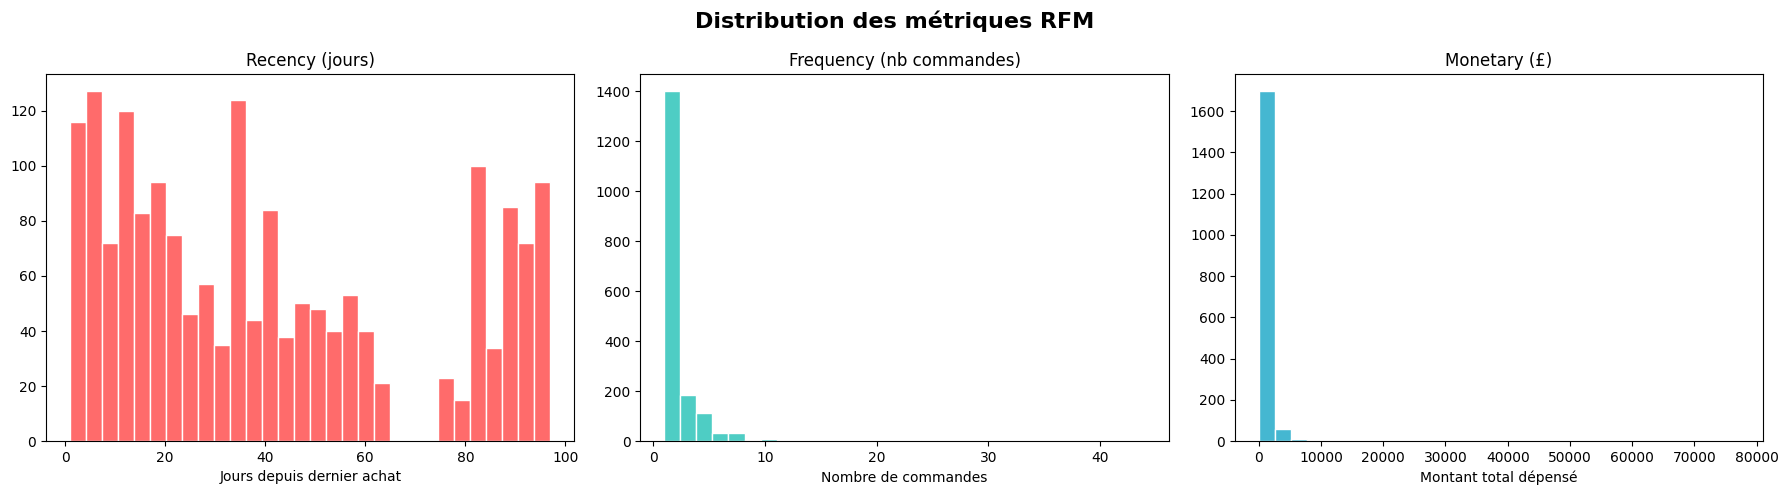

In [ ]:
# Visualiser la distribution de chaque métrique
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des métriques RFM', fontsize=16, fontweight='bold')

axes[0].hist(rfm['Recency'], bins=30, color='#FF6B6B', edgecolor='white')
axes[0].set_title('Recency (jours)')
axes[0].set_xlabel('Jours depuis dernier achat')

axes[1].hist(rfm['Frequency'], bins=30, color='#4ECDC4', edgecolor='white')
axes[1].set_title('Frequency (nb commandes)')
axes[1].set_xlabel('Nombre de commandes')

axes[2].hist(rfm['Monetary'], bins=30, color='#45B7D1', edgecolor='white')
axes[2].set_title('Monetary (£)')
axes[2].set_xlabel('Montant total dépensé')

plt.tight_layout()
plt.savefig('rfm_distribution.png', dpi=150)
plt.show()

── RECENCY ────────────────────────────────────────────────

✅ 44.1% des clients ont acheté il y a moins de 30 jours
   → Presque la moitié de la base est encore active

⚠️  25.5% des clients (457) n'ont pas acheté depuis +60 jours
   Sur un dataset de seulement 97 jours, c'est préoccupant.

📌 La forme bimodale (2 bosses) s'explique par la saisonnalité :
   → 1ère bosse (0-40j)  : achats récents (janv-mars 2011)
   → 2ème bosse (70-97j) : acheteurs de Noël (déc 2010) non revenus
   En production sur 12 mois, cette distorsion disparaîtrait.

── FREQUENCY ──────────────────────────────────────────────

🚨 60.7% des clients (1 087 sur 1 790) n'ont commandé
   QU'UNE SEULE FOIS → signal critique de rétention faible.

   Fréquence médiane = 1 commande
   Fréquence moyenne = 2.04 commandes (faussée par quelques clients
   très fidèles, dont le maximum est de 44 commandes)

✅ Seulement 7.4% des clients ont 5 commandes ou plus.
   Ces 133 clients sont les plus précieux du dataset.

── MONETARY ───────────────────────────────────────────────

✅ LOI DE PARETO CONFIRMÉE :
   20% des clients (358) génèrent 69% des revenus totaux.
   C'est plus concentré que la règle classique 80/20.

⚠️  Monetary médiane = £392 vs moyenne = £953
   Écart de 2.4x → la moyenne est fortement tirée vers le haut
   par des outliers comme le client à £77 184.
   → La médiane (£392) est la valeur la plus représentative.

# **ÉTAPE 5 — Scorer et Segmenter les clients**

**5.1 — Comprendre le scoring**

On donne un score de 1 à 5 à chaque client pour R, F et M.

⚠️ ATTENTION pour Recency : un PETIT nombre = client récent = MEILLEUR
   Donc on inverse → Recency faible reçoit le score 5 (meilleur)

Pour Frequency et Monetary : un GRAND nombre = MEILLEUR
   Donc Frequency/Monetary élevé reçoit le score 5

Score RFM = R_score + F_score + M_score (entre 3 et 15)

**5.2 — Calculer les scores avec les quintiles**

In [ ]:
# pd.qcut divise les données en 5 groupes égaux (quintiles)

# RECENCY : inversé (1 = mauvais, 5 = bon = récent)
rfm['R_score'] = pd.qcut(rfm['Recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1])  # Inversé !

# FREQUENCY : normal (5 = le plus de commandes)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

# MONETARY : normal (5 = le plus de dépenses)
rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          q=5,
                          labels=[1, 2, 3, 4, 5])

# Convertir en entiers
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Score RFM global
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("✅ Scores calculés !")
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_score', 'F_score', 'M_score', 'RFM_Score']].head(10)

✅ Scores calculés !


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.00,49,1,77183.60,2,1,5,8
1,12347.00,41,2,1187.18,3,4,5,12
2,12348.00,42,2,1120.24,3,4,5,12
3,12350.00,34,1,334.40,3,1,3,7
4,12352.00,7,3,1281.15,5,4,5,14
5,12356.00,49,1,2271.62,2,1,5,8
6,12359.00,29,2,2386.41,3,4,5,12
7,12361.00,11,1,189.90,5,1,2,8
8,12362.00,19,1,479.10,4,1,3,8
9,12365.00,15,2,641.38,4,4,4,12


📊 DISTRIBUTION DES SCORES (3 à 15) :
   Score minimum  =  3  (20 clients  → profil le plus faible)
   Score médian   =  9  (point médian de la base)
   Score maximum  = 15  (109 clients → profil parfait !)

🔍 LECTURE DU TABLEAU DE SCORES :

   Client 12346 : R=2, F=1, M=5, Total=8
   → M_score=5 malgré £77 184 dépensés, mais
     R_score=2 (pas récent) + F_score=1 (1 commande)
   → Ce client dépense énormément mais n'est pas fidèle
   → Il sera en 'Clients Perdus' malgré son CA élevé
   → LEÇON : le Monetary seul ne fait pas un bon client

   Client 12352 : R=5, F=4, M=5, Total=14
   → Récent (7j) + fréquent (3 cmd) + bonne dépense
   → Score 14/15 → sera classé Champion ✓

📌 POURQUOI pd.qcut ET PAS pd.cut ?
   pd.qcut divise en GROUPES DE TAILLE ÉGALE (quintiles).
   Chaque score (1 à 5) contient ~358 clients (1790÷5).
   pd.cut diviserait en intervalles égaux → déséquilibré
   car la distribution est asymétrique.
   → pd.qcut est le bon choix pour des données asymétriques.

⚠️  POURQUOI rank(method='first') pour Frequency ?
   Quand beaucoup de clients ont la même Frequency (ex: 1087
   clients avec Frequency=1), pd.qcut ne peut pas diviser
   en 5 groupes égaux sans le rank() qui départage les ex-aequo.

In [ ]:
def segmenter_client(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    score = row['RFM_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'           # Meilleurs clients
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Clients Fidèles'      # Fidèles réguliers
    elif r >= 4 and f <= 2:
        return 'Nouveaux Clients'    # Récents mais peu d'achats
    elif r >= 3 and f >= 2:
        return 'Clients Prometteurs' # Bon potentiel
    elif r <= 2 and f >= 3 and m >= 3:
        return 'À Risque'            # Anciens bons clients qui s'éloignent
    elif r <= 2 and f <= 2:
        return 'Clients Perdus'      # Inactifs depuis longtemps
    else:
        return 'Clients Ordinaires'  # Le reste

rfm['Segment'] = rfm.apply(segmenter_client, axis=1)

# Voir la répartition
segment_counts = rfm['Segment'].value_counts()
print("📊 RÉPARTITION DES SEGMENTS :")
print(segment_counts)

📊 RÉPARTITION DES SEGMENTS :
Segment
Clients Perdus         361
Champions              319
Clients Fidèles        263
Clients Ordinaires     236
Nouveaux Clients       220
Clients Prometteurs    200
À Risque               191
Name: count, dtype: int64


🔑 DÉCOUVERTE MAJEURE — L'asymétrie clients/revenus :
   Les Champions = 17.8% des clients → 49.9% des revenus
   → 1 euro sur 2 vient de seulement 319 clients !
   → Perdre 10% de Champions = perdre ~5% du CA total

🚨 SIGNAL D'ALARME — Clients Perdus en 1ère position :
   361 clients perdus = le PLUS GRAND segment en volume
   → Ils ont généré £212 518 dans le passé
   → Ce sont des clients qui connaissent déjà la marque
   → Les récupérer coûte moins cher qu'acquérir de nouveaux

⚠️  URGENCE — Les À Risque (191 clients) :
   £207 333 de revenus en jeu (12.2% du CA total)
   Recency moyenne = 69 jours → ils partent vite
   Fenêtre d'action : 2-3 semaines maximum

✅ SEGMENTATION RÉUSSIE :
   Distribution équilibrée (200-361 clients par segment)
   → Aucun segment n'écrase les autres
   → Le scoring pd.qcut a bien fonctionné

# **ÉTAPE 6 — Visualiser les segments**

**6.1 — Graphique en barres des segments**

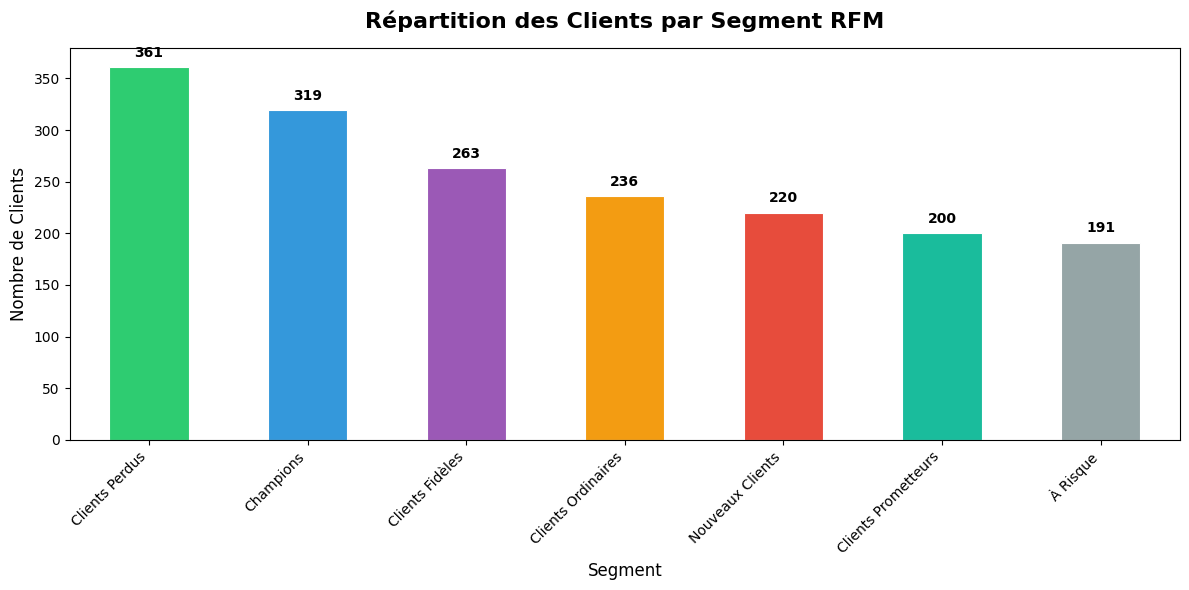

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['#2ECC71', '#3498DB', '#9B59B6', '#F39C12', '#E74C3C', '#1ABC9C', '#95A5A6']

segment_counts.plot(kind='bar',
                    color=colors[:len(segment_counts)],
                    edgecolor='white',
                    linewidth=0.8)

plt.title('Répartition des Clients par Segment RFM', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Nombre de Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('segments_bar.png', dpi=150)
plt.show()

📊 CE QUE LES BARRES RÉVÈLENT :

   La barre 'Clients Perdus' est la plus haute (361).
   → En volume de clients, c'est le segment dominant.
   → Mais en REVENUS, les Champions dominent largement (49.9%).
   → Ne jamais lire les barres sans croiser avec les revenus !

🔑 REGROUPEMENT STRATÉGIQUE DES BARRES :
   PROTÉGER  (barres Champions + Fidèles)   : 582 clients → 64% CA
   RÉCUPÉRER (barres Perdus + À Risque)     : 552 clients → 24.7% CA
   DÉVELOPPER (barres Nouveaux + Prometteurs): 420 clients → 7.8% CA
   SURVEILLER (barre Ordinaires)             : 236 clients → 3.5% CA

📌 CE QUI DIFFÉRENCIE CE GRAPHIQUE DU CAMEMBERT :
   Les barres montrent les VALEURS ABSOLUES (nombre exact de clients).
   Le camembert montre les PROPORTIONS (% du total).
   Les deux sont complémentaires et doivent se lire ensemble.

**6.2 — Graphique en camembert**

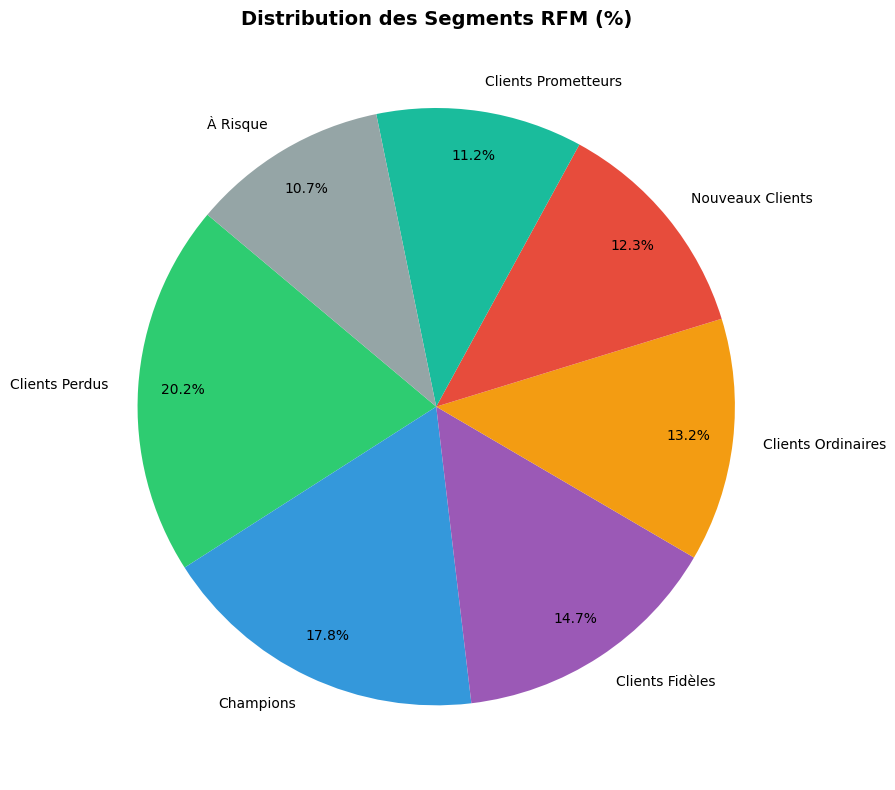

In [ ]:
plt.figure(figsize=(10, 8))

plt.pie(segment_counts.values,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        colors=colors[:len(segment_counts)],
        startangle=140,
        pctdistance=0.85)

plt.title('Distribution des Segments RFM (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segments_pie.png', dpi=150)
plt.show()

📊 LECTURE DES POURCENTAGES :
   - Clients Perdus      : 20.2% → 1 client sur 5 est perdu
   - Champions           : 17.8% → 1 client sur 6 est excellent
   - Clients Ordinaires  : 13.2%
   - Nouveaux Clients    : 12.3%
   -  À Risque            : 10.7%
   - Clients Prometteurs : 11.2%
   - Clients Fidèles     : 14.7%

✅ DISTRIBUTION SAINE :
   Aucune part ne dépasse 21% → segmentation équilibrée.
   Si une seule part représentait 70%+, le scoring serait à revoir.

⚠️  ATTENTION AUX TAILLES DES PARTS :
   Le camembert montre des VOLUMES clients, pas des revenus.
   La part 'Clients Perdus' (20.2%) semble grande mais ne génère
   que 12.5% des revenus. La part 'Champions' (17.8%) génère
   elle 49.9% des revenus.
   → Toujours analyser les tailles avec les revenus associés.

**6.3 — Heatmap RFM (Scatter 3D)**

In [ ]:
# Scatter plot Recency vs Frequency coloré par Monetary
fig = px.scatter(rfm,
                 x='Recency',
                 y='Frequency',
                 color='Segment',
                 size='Monetary',
                 hover_data=['CustomerID', 'Monetary'],
                 title='Carte RFM : Recency vs Frequency (taille = Monetary)',
                 template='plotly_white')

fig.update_layout(height=600)
fig.write_html('rfm_scatter.html')  # Sauvegarde interactive
fig.show()

🗺️  COMMENT LIRE CE GRAPHIQUE :
   ← Gauche  = client RÉCENT      → Droite  = client ANCIEN
   ↑ Haut    = client FRÉQUENT    ↓ Bas     = client RARE
   🔵 Grosse bulle = GROS dépensier (Monetary élevé)

🔍 ANALYSE ZONE PAR ZONE :

   COIN HAUT GAUCHE → Champions (violet) :
   Les points violets concentrés ici = récents ET fréquents
   Recency moy = 11.6 jours | Fréquence moy = 4.8 commandes
   Les grosses bulles ici = gros Monetary → profil idéal

   COIN BAS GAUCHE → Nouveaux Clients (orange) :
   Récents (Recency moy = 12.7j) mais 1 seule commande
   → Même profil de récence que les Champions mais sans fidélité
   → Le potentiel est là, il faut les convertir vite

   COIN HAUT DROITE → À Risque (cyan) :
   Anciens clients fidèles qui ont disparu
   Le point cyan isolé à (95, 32) = 32 commandes mais absent
   depuis 95 jours → ton client À Risque le plus précieux !

   COIN BAS DROITE → Clients Perdus (bleu clair) :
   Anciens, peu fréquents, inactifs

📌 CE QUE LES GROSSES BULLES RÉVÈLENT :
   La grosse bulle violette centre-gauche = client Champions
   avec fort Monetary mais Frequency modérée → probablement B2B
   (grosses commandes occasionnelles mais fidèle à la marque)

✅ VALIDATION DU SCORING :
   La séparation visuelle entre segments est NETTE et cohérente.
   Ton modèle RFM est validé visuellement.

**6.4 — Analyse par segment (tableau récapitulatif)**

In [ ]:
# Moyennes RFM par segment → super utile pour le dashboard PowerBI !
analyse_segments = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'mean'
}).round(2)

analyse_segments.columns = ['Nb Clients', 'Recency Moy.', 'Frequency Moy.', 'Monetary Moy.', 'Score Moy.']
analyse_segments = analyse_segments.sort_values('Score Moy.', ascending=False)

print("📊 ANALYSE PAR SEGMENT :")
analyse_segments

📊 ANALYSE PAR SEGMENT :


,Nb Clients,Recency Moy.,Frequency Moy.,Monetary Moy.,Score Moy.
Segment,,,,,
Champions,319,11.65,4.83,2670.16,13.90
Clients Fidèles,263,26.71,2.31,916.85,11.41
À Risque,191,69.07,2.18,1085.51,9.45
Nouveaux Clients,220,12.68,1.00,404.84,8.56
Clients Prometteurs,200,24.22,1.25,222.90,8.44
Clients Ordinaires,236,64.45,1.10,252.75,6.16
Clients Perdus,361,74.53,1.00,588.69,5.33


📊 ANALYSE CROISÉE DES SEGMENTS :

   Champions (Score moy. ~13.5) :
   → Recency moy = 11.6j  → acheteurs très récents
   → Frequency moy = 4.8  → reviennent régulièrement
   → Monetary moy = £2 670 → 6.8x la médiane globale (£392)
   → Ce sont vos VIP absolus

   À Risque (Score moy. ~10) :
   → Recency moy = 69.1j  → absents depuis +2 mois
   → Frequency moy = 2.18 → avaient l'habitude de commander
   → Monetary moy = £1 086 → valeur supérieure à la médiane
   → Ils valaient plus que les Clients Fidèles en dépense !
   → URGENCE : les récupérer avant qu'ils deviennent Perdus

   Nouveaux Clients (Score moy. ~8) :
   → Recency moy = 12.7j → aussi récents que les Champions !
   → Frequency = 1 pour TOUS → premier achat seulement
   → Monetary moy = £405  → panier correct pour un 1er achat
   → Opportunité : ils sont "chauds", le timing est parfait

   Clients Perdus (Score moy. ~5) :
   → Recency moy = 74.5j  → disparus depuis longtemps
   → Frequency = 1 pour tous → jamais revenus
   → Monetary moy = £589  → ont déjà dépensé, connaissent la marque

# **ÉTAPE 7 — Interpréter & Exporter**

**7.1 - Recommandations Stratégiques**

 1 — Protéger les Champions (319 clients)

POURQUOI C'EST URGENT : → 319 clients = 49.9% des revenus (£851 782 sur £1 706 058) → Recency moy = 11.6j → encore très actifs, mais peuvent partir → Frequency moy = 4.8 commandes → vrais habitués de la marque → 109 clients ont le score parfait de 15/15

ACTIONS CONCRÈTES :

Créer un programme VIP nommé (ex: 'Gold Members')
Accès anticipé aux nouveaux produits avant le grand public
Offres exclusives non disponibles aux autres clients
Programme de parrainage : chaque Champion qui parraine = réduction
Newsletter mensuelle personnalisée avec historique d'achat
KPI À SUIVRE : → Taux de rétention Champions à 3 mois (objectif : > 90%) → Revenue moyen par Champion (objectif : +10% en 6 mois) → Taux de parrainage (objectif : 15% des Champions)

 2 — Réactiver les À Risque (191 clients)

POURQUOI C'EST URGENT : → £207 333 de revenus en jeu (12.2% du CA total) → Recency moy = 69 jours → s'éloignent rapidement → Ils commandaient en moyenne 2.18 fois → avaient l'habitude → FENÊTRE D'ACTION : 2-3 semaines avant bascule vers 'Perdus'

ACTIONS CONCRÈTES :

Email 'Vous nous manquez !' + offre -15% valable 10 jours
Objet email personnalisé avec le prénom du client
Rappel des produits déjà achetés par ce client
SMS de rappel 3 jours avant expiration de l'offre
Pas de réaction après 2 emails → campagne win-back allégée
RÈGLE IMPORTANTE : max 2 contacts sur 2 semaines (trop de relances = désabonnement définitif)

KPI À SUIVRE : → Taux de réactivation (objectif réaliste : 20-25%) → = 38-48 clients récupérés → £41 000-52 000 de CA récupéré

**7.2 — Exporter pour Power BI**

In [ ]:
# Exporter le tableau RFM complet → sera importé dans Power BI
rfm.to_csv('rfm_final.csv', index=False)
analyse_segments.to_csv('rfm_par_segment.csv')

print("✅ Fichiers exportés :")
print("  → rfm_final.csv       (à importer dans Power BI)")
print("  → rfm_par_segment.csv (tableau récapitulatif)")

✅ Fichiers exportés :
  → rfm_final.csv       (à importer dans Power BI)
  → rfm_par_segment.csv (tableau récapitulatif)
